In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [176]:
#Loading, nan replacements, and sanity checks
df = pd.read_csv('electricity-demand-dataset.csv')
df = df.drop('Temperature', axis = 1)
df = df.drop('Humidity', axis = 1)

#fixing rows with no data and resetting indexes
df = df.drop([10004, 10005, 10006, 10007])
df = df.reset_index(drop=True)

#fixing nans in each column
for i in df.index:

    #--- hour ---
    if pd.isna(df.loc[i, 'hour']):
        df.loc[i, 'hour'] = (df.loc[i-1, 'hour'] + 1) % 23

    # --- dayofweek ---
    if pd.isna(df.loc[i, 'dayofweek']):
        if df.loc[i, 'hour'] != 0:
            df.loc[i, 'dayofweek'] = df.loc[i-1, 'dayofweek']
        else:
            df.loc[i, 'dayofweek'] = (df.loc[i-1, 'dayofweek'] + 1) % 7

    # --- month ---
    if pd.isna(df.loc[i, 'month']):
        ts = pd.to_datetime(df.loc[i, 'Timestamp'])
        if ts.day != 1:
            df.loc[i, 'month'] = df.loc[i-1, 'month']
        else:
            df.loc[i, 'month'] = df.loc[i+1, 'month']

    # --- year ---
    if pd.isna(df.loc[i, 'year']):
        ts = pd.to_datetime(df.loc[i, 'Timestamp'])
        if not (ts.month == 1 and ts.day == 1):
            df.loc[i, 'year'] = df.loc[i-1, 'year']
        else:
            df.loc[i, 'year'] = df.loc[i+1, 'year']

    # --- dayofyear ---
    if pd.isna(df.loc[i, 'dayofyear']):
        if df.loc[i, 'hour'] != 0:
            df.loc[i, 'dayofyear'] = df.loc[i-1, 'dayofyear']
        else:
            df.loc[i, 'dayofyear'] = df.loc[i-1, 'dayofyear'] + 1

    # --- Demand ---
    if pd.isna(df.loc[i, 'Demand']):
        df.loc[i, 'Demand'] = (df.loc[i-1, 'Demand'] + df.loc[i+1, 'Demand']) / 2

#checking nan counts per col
cols = ['Timestamp', 'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'Demand']

print(df[cols].isna().sum())

for col in cols:
    nan_idx = df[df[col].isna()].index
    print(f"{col} NaN indices:", nan_idx.tolist())


Timestamp    0
hour         0
dayofweek    0
month        0
year         0
dayofyear    0
Demand       0
dtype: int64
Timestamp NaN indices: []
hour NaN indices: []
dayofweek NaN indices: []
month NaN indices: []
year NaN indices: []
dayofyear NaN indices: []
Demand NaN indices: []


In [177]:
#sin encoding repeating times and dropping absolute information

df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['dow_sin'] = np.sin(2*np.pi*df['dayofweek']/7)
df['dow_cos'] = np.cos(2*np.pi*df['dayofweek']/7)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df['doy_sin'] = np.sin(2*np.pi*df['dayofyear']/365)
df['doy_cos'] = np.cos(2*np.pi*df['dayofyear']/365)

df = df.drop(columns=['hour','dayofweek','dayofyear','Timestamp','month'])

print(df.head())

     year       Demand  hour_sin  hour_cos   dow_sin   dow_cos  month_sin  \
0  2020.0  2457.119872  0.000000  1.000000  0.974928 -0.222521        0.5   
1  2020.0  2269.904712  0.258819  0.965926  0.974928 -0.222521        0.5   
2  2020.0  2215.640403  0.500000  0.866025  0.974928 -0.222521        0.5   
3  2020.0  2174.232413  0.707107  0.707107  0.974928 -0.222521        0.5   
4  2020.0  2472.453006  0.866025  0.500000  0.974928 -0.222521        0.5   

   month_cos   doy_sin   doy_cos  
0   0.866025  0.017213  0.999852  
1   0.866025  0.017213  0.999852  
2   0.866025  0.017213  0.999852  
3   0.866025  0.017213  0.999852  
4   0.866025  0.017213  0.999852  


In [180]:
#Split into training and testing. Further split into features and labels.
train_df = df[df['year'] != 2024]
test_df  = df[df['year'] == 2024]

train_df = train_df.drop('year', axis = 1)
test_df = test_df.drop('year', axis = 1)

X_train = train_df.drop(columns=['Demand']) #training features
y_train = train_df['Demand'] #training labels

X_test = test_df.drop(columns=['Demand']) #testing features
y_test = test_df['Demand'] #testing labels

X_train.head()

,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos
0,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,0.017213,0.999852
1,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,0.017213,0.999852
2,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025,0.017213,0.999852
3,0.707107,0.707107,0.974928,-0.222521,0.5,0.866025,0.017213,0.999852
4,0.866025,0.500000,0.974928,-0.222521,0.5,0.866025,0.017213,0.999852


In [182]:
#Scaling labels in training data
from sklearn.preprocessing import MinMaxScaler

# Scale demand
y_train = y_train.to_frame(name='Demand')
print(y_train.shape)
print(X_train.shape)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)


(35060, 1)
(35060, 8)


In [184]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

# -----------------------------
# 1) Prepare features and target
# -----------------------------
features = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
            'month_sin', 'month_cos', 'doy_sin', 'doy_cos']

X = X_train[features].values

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1,1)

print(np.isnan(X.numpy()).any(), np.isinf(X.numpy()).any())#Checks for nans again
print(np.isnan(y.numpy()).any(), np.isinf(y.numpy()).any())

False False
False False


In [186]:
# -----------------------------
# 2) Build overfitting DNN
# -----------------------------
model = nn.Sequential(
    nn.Linear(len(features), 512),
    nn.ReLU(),
    nn.Linear(512, 1028),
    nn.ReLU(),
    nn.Linear(1028, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [188]:
# -----------------------------
# 3) Loss and optimizer
# -----------------------------
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [190]:
# -----------------------------
# 4) Training loop
# -----------------------------
for epoch in range(1000):  # small dataset → overfits easily
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.2f}")


Epoch 0, Loss: 0.22
Epoch 50, Loss: 0.00
Epoch 100, Loss: 0.00
Epoch 150, Loss: 0.00
Epoch 200, Loss: 0.00
Epoch 250, Loss: 0.00
Epoch 300, Loss: 0.00
Epoch 350, Loss: 0.00
Epoch 400, Loss: 0.00
Epoch 450, Loss: 0.00
Epoch 500, Loss: 0.00
Epoch 550, Loss: 0.00
Epoch 600, Loss: 0.00
Epoch 650, Loss: 0.00
Epoch 700, Loss: 0.00
Epoch 750, Loss: 0.00
Epoch 800, Loss: 0.00
Epoch 850, Loss: 0.00
Epoch 900, Loss: 0.00
Epoch 950, Loss: 0.00


In [192]:
#Generating scaled predictions

# Make sure X_train/X_test are torch tensors of type float
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)

model.eval()  # disables dropout, batchnorm updates, etc.

with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).numpy()
    y_test_pred_scaled  = model(X_test_tensor).numpy()

y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled)

# Make sure the true labels are also in the same shape
y_train_real = y_train
y_test_real  = y_test

NOTE TO SELF: for very strictly sampled time series data, you dont actually need a DNN to create a very overfitted curve. All you need is a lookup table and an interpolator. But if you have a lot of data, you don't even need the DNN interpolator, even a linear one would work. Where DNNs are helpful are creating interpolating functions for irregularly spaced data that you can then sample at regular intervals to get an array you can FFT. 

In [737]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error, median_absolute_error, explained_variance_score, max_error

def regression_metrics_extended(y_train_true, y_train_pred, y_test_true, y_test_pred):

    def compute_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        msle = mean_squared_log_error(y_true, y_pred)   # y_true >= 0
        medae = median_absolute_error(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
        maxe = max_error(y_true, y_pred)

        return {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "MSLE": msle,
            "MedAE": medae,
            "ExplainedVariance": evs,
            "MaxError": maxe
        }

    train_metrics = compute_metrics(y_train_true, y_train_pred)
    test_metrics  = compute_metrics(y_test_true, y_test_pred)

    # -------- Pretty table output --------
    print("\nRegression Metrics\n")

    header = f"{'Metric':<20}{'Train':>15}{'Test':>15}"
    print(header)
    print("-" * len(header))

    for key in train_metrics:
        print(f"{key:<20}{train_metrics[key]:>15.6f}{test_metrics[key]:>15.6f}")

    return train_metrics, test_metrics


train_metrics = regression_metrics_extended(y_train_real, y_train_pred, y_test_real, y_test_pred) 





Regression Metrics

Metric                        Train           Test
--------------------------------------------------
RMSE                     202.796224     274.646791
MAE                      159.128189     215.956945
R2                         0.979350       0.962207
MSLE                       0.002013       0.003287
MedAE                    134.270492     189.689866
ExplainedVariance          0.980870       0.979151
MaxError                3420.580883    4338.947776


In [ ]:
#Generating sine encoded input data to probe DNN's regression curve

In [749]:
# Example: full year 2024
start = pd.Timestamp('2024-01-01 00:00:00')
end   = pd.Timestamp('2024-12-31 23:30:00')

time_index = pd.date_range(start=start, end=end, freq='60min')
print(time_index)

DatetimeIndex(['2024-01-01 00:00:00', '2024-01-01 01:00:00',
               '2024-01-01 02:00:00', '2024-01-01 03:00:00',
               '2024-01-01 04:00:00', '2024-01-01 05:00:00',
               '2024-01-01 06:00:00', '2024-01-01 07:00:00',
               '2024-01-01 08:00:00', '2024-01-01 09:00:00',
               ...
               '2024-12-31 14:00:00', '2024-12-31 15:00:00',
               '2024-12-31 16:00:00', '2024-12-31 17:00:00',
               '2024-12-31 18:00:00', '2024-12-31 19:00:00',
               '2024-12-31 20:00:00', '2024-12-31 21:00:00',
               '2024-12-31 22:00:00', '2024-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8784, freq='60min')


In [751]:
df_features = pd.DataFrame({
    'hour'  : time_index.hour + time_index.minute / 60.0,  # 0-23.5
    'dow'   : time_index.dayofweek,                        # 0=Mon, 6=Sun
    'month' : time_index.month,                             # 1-12
    'doy'   : time_index.dayofyear                          # 1-366
})

In [753]:
def sine_cosine_encode(df):
    # Hour: 24h cycle
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
    
    # Day of week: 7-day cycle
    df['dow_sin']  = np.sin(2*np.pi*df['dow']/7)
    df['dow_cos']  = np.cos(2*np.pi*df['dow']/7)
    
    # Month: 12-month cycle
    df['month_sin'] = np.sin(2*np.pi*(df['month']-1)/12)
    df['month_cos'] = np.cos(2*np.pi*(df['month']-1)/12)
    
    # Day of year: 365-day cycle
    df['doy_sin'] = np.sin(2*np.pi*(df['doy']-1)/365)
    df['doy_cos'] = np.cos(2*np.pi*(df['doy']-1)/365)
    
    return df[['hour_sin','hour_cos','dow_sin','dow_cos',
               'month_sin','month_cos','doy_sin','doy_cos']]

X_sample = sine_cosine_encode(df_features)

In [755]:
X_sample_tensor = torch.tensor(X_sample.values, dtype=torch.float32)

In [757]:
model.eval()
with torch.no_grad():
    y_sample_scaled = model(X_sample_tensor).numpy()

In [759]:
y_sample = scaler_y.inverse_transform(y_sample_scaled)

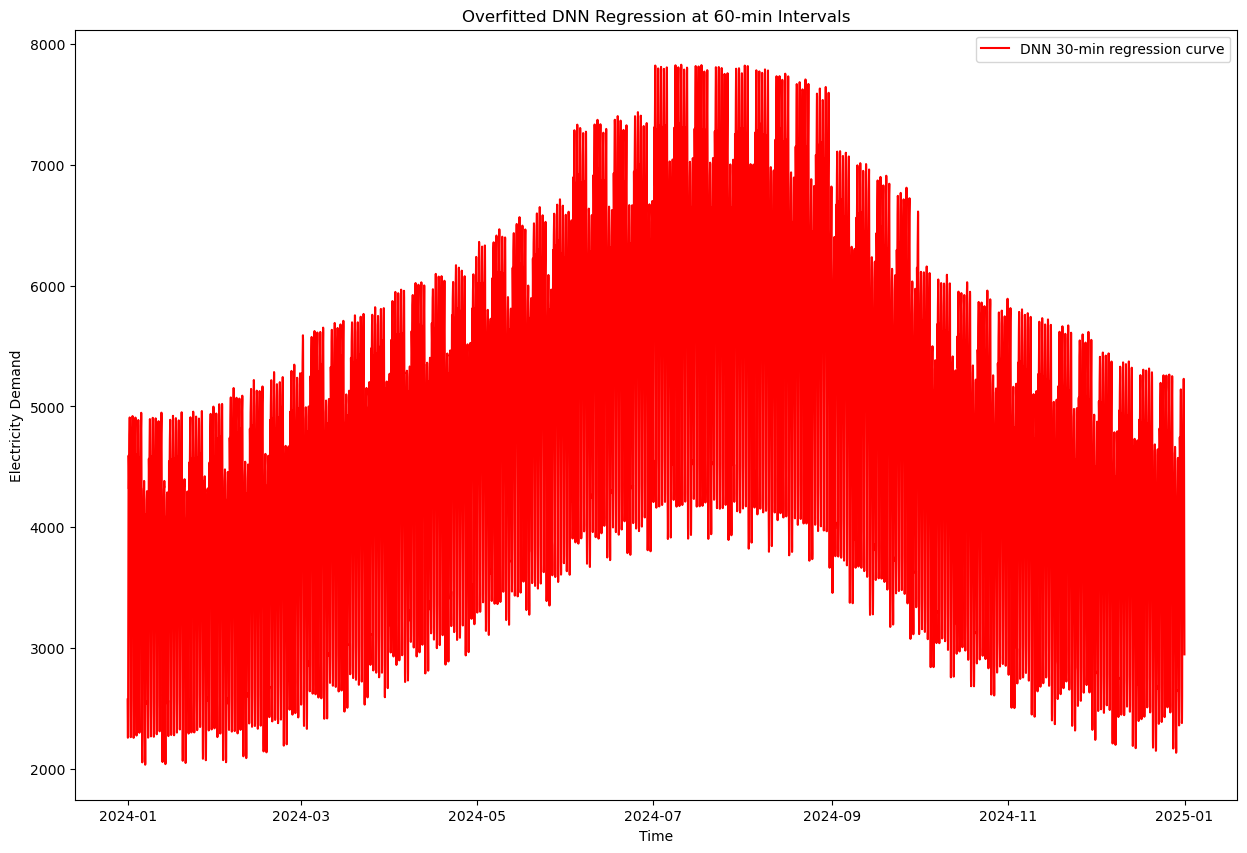

In [763]:
plt.figure(figsize=(15,10))
plt.plot(time_index, y_sample, color='red', label='DNN 30-min regression curve')
plt.xlabel('Time')
plt.ylabel('Electricity Demand')
plt.title('Overfitted DNN Regression at 60-min Intervals')
plt.legend()
plt.show()

In [765]:
print(y_sample) #y_sample is an array of arrays, hence must be flattened

[[2576.75  ]
 [2374.5742]
 [2260.0906]
 ...
 [3908.7683]
 [3327.5405]
 [2949.391 ]]


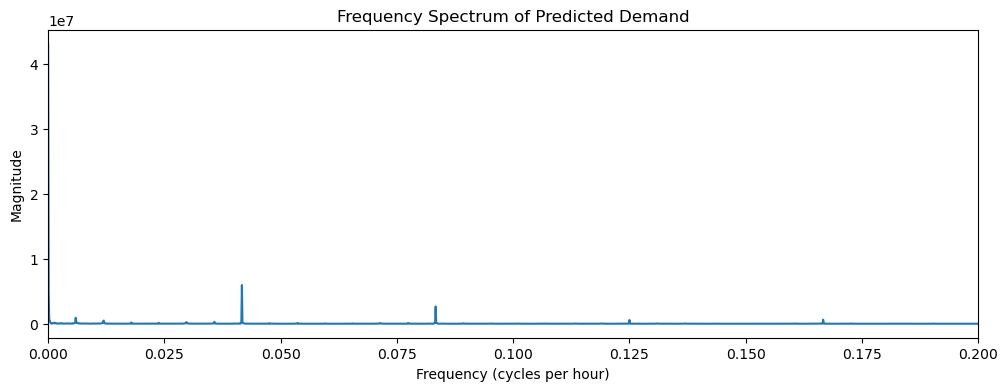

[4.30813077e+07 5.00619669e+06 6.56549720e+05 ... 7.47897517e+02
 3.27972721e+03 6.59034035e+03]


In [767]:
#Starting to compute FFT

# y_sample is a 1D NumPy array of demand values sampled every 1 minute
# For FFT, it's better to flatten it
y_signal = y_sample.flatten()

# Number of samples
N = len(y_signal)

# Sampling interval: 60 min → in hours
dt = 1  # 60 minute = 1 hour

# FFT
Y_fft = np.fft.fft(y_signal)

# Frequencies
freqs = np.fft.fftfreq(N, dt)

# Only keep the positive half (real signal)
pos_mask = freqs >= 0
pos_freqs = freqs[pos_mask]
pos_Y_fft = Y_fft[pos_mask]

# Magnitude spectrum
magnitude = np.abs(pos_Y_fft)

plt.figure(figsize=(12,4))
plt.plot(pos_freqs, magnitude)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of Predicted Demand')
plt.xlim(0, 0.2)  # Optional: zoom in on low frequencies
plt.show()

print(magnitude)

When sampling the overfitted curve to input points into the FFT keep 2 things in mind:
1. Oversampling is much better than undersampling. The traditional risk of oversampling is that it introduces non existent high frequencies into the FFT. But these get eliminated when we do an LPF. So there is no risk of oversampling whatsoever.
2. It is usually easier to sample at a frequency such that the number of points you obtain are equal to the number of datapoints in our test data and correspond 1-1 with the test data. For example, in this case we first probed the DNN to find the regression curve over 1 year- Jan 1st to Dec 31st. This corresponds 1-1 with our testing data. Then we sampled the DNN curve at every hour, which is also the case for test data. Thus, we got to compare hourly data for a year with hourly data for a year when calculating error metrics. I'm sure there are ways of dealing with it if this 1-1 correspondance doesnt exist, but it's easy to compute everything if you can manufacture it.

In [769]:
for i in range(100):
    print('Magnitude is ', magnitude[i], 'at frequency ', pos_freqs[i])

Magnitude is  43081307.71557617 at frequency  0.0
Magnitude is  5006196.6857267795 at frequency  0.00011384335154826958
Magnitude is  656549.7201150547 at frequency  0.00022768670309653916
Magnitude is  485236.5908912018 at frequency  0.00034153005464480874
Magnitude is  221220.34459537012 at frequency  0.0004553734061930783
Magnitude is  52897.67331615099 at frequency  0.000569216757741348
Magnitude is  26628.832533373836 at frequency  0.0006830601092896175
Magnitude is  23173.84018947807 at frequency  0.000796903460837887
Magnitude is  54737.70336397226 at frequency  0.0009107468123861566
Magnitude is  122593.54486658194 at frequency  0.0010245901639344263
Magnitude is  101066.94707779927 at frequency  0.001138433515482696
Magnitude is  163847.96601462725 at frequency  0.0012522768670309653
Magnitude is  34727.82696359483 at frequency  0.001366120218579235
Magnitude is  140887.79929693206 at frequency  0.0014799635701275046
Magnitude is  87432.18971076209 at frequency  0.001593806921

In [1026]:
# --- Step 2: Create LPF mask ---
f_cutoff = 0.1  # cycles per minute (adjust to keep desired smoothness)
lpf_mask = np.abs(freqs) < f_cutoff  # True for frequencies below cutoff

# --- Step 3: Apply LPF ---
Y_fft_lpf = Y_fft * lpf_mask
Y_fft_lpf_1d = Y_fft_lpf.flatten()

print(freqs.shape, Y_fft_lpf_1d.shape)

(8784,) (8784,)


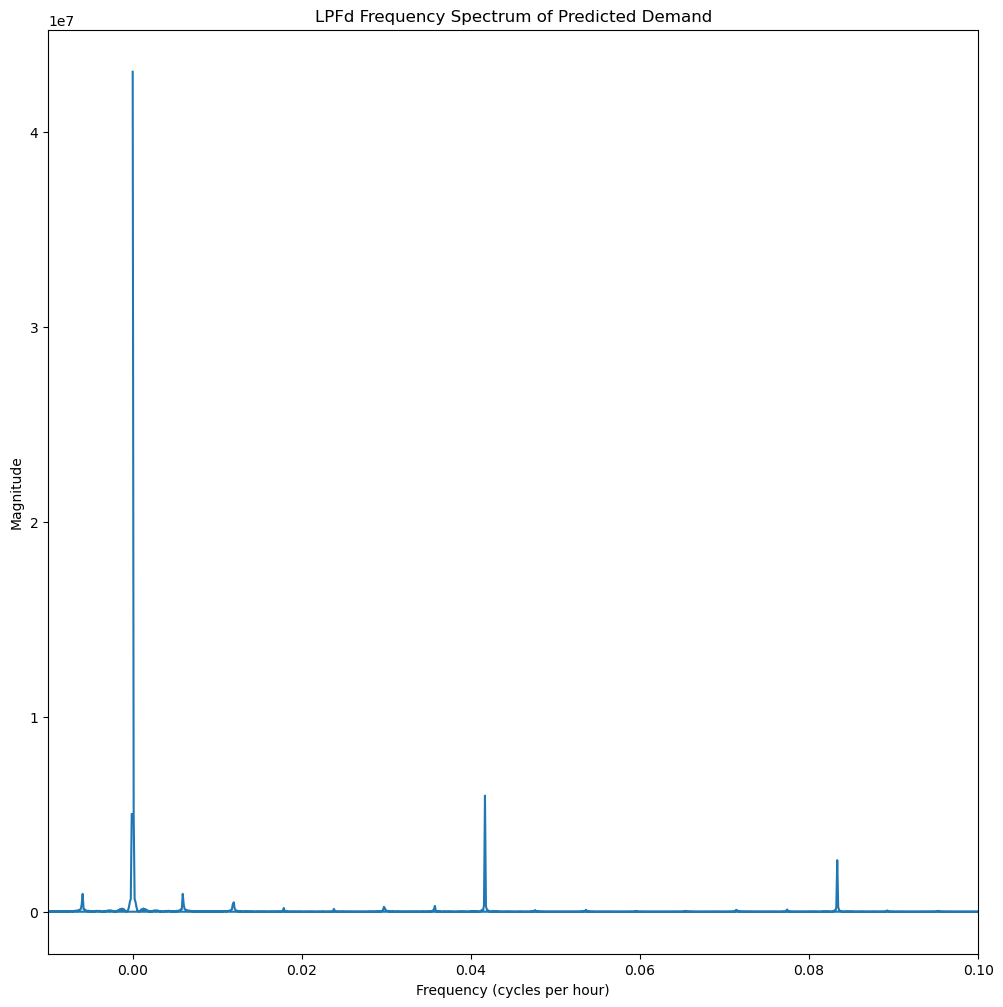

In [1028]:
plt.figure(figsize=(12,12))
plt.plot(freqs, np.real(np.abs(Y_fft_lpf_1d)))
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Magnitude')
plt.title('LPFd Frequency Spectrum of Predicted Demand')
plt.xlim(-0.01,0.1)
plt.show()

In [1030]:
# --- Step 4: Inverse FFT ---
y_time_domain = np.fft.ifft(Y_fft_lpf).real  # real-valued time-domain signal
adjustment = (np.mean(test_df['Demand']) - np.mean(train_df['Demand']))
y_time_domain_adjusted = y_time_domain + adjustment
print(adjustment)

127.32116993819363


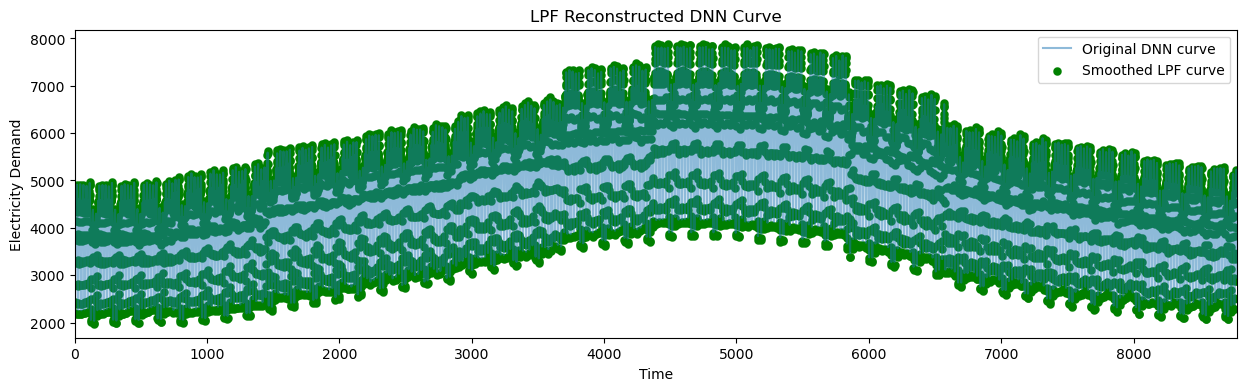

In [1032]:

plt.figure(figsize=(15,4))
plt.plot(y_signal, alpha=0.5, label='Original DNN curve')
plt.scatter(range(len(y_time_domain)), y_time_domain, color='green', label='Smoothed LPF curve', linewidth = 0.1)
#plt.scatter(range(len(y_time_domain)), y_time_domain_adjusted, color='orange', label='Smoothed LPF curve (mean adjusted)', linewidth = 0.1)
plt.xlabel('Time')
plt.ylabel('Electricity Demand')
plt.title('LPF Reconstructed DNN Curve')
plt.xlim(0,len(y_time_domain))
plt.legend()
plt.show()

In [1034]:
print(y_time_domain.shape)
print(y_signal.shape)

(8784,)
(8784,)


NOTE TO SELF: This algorithm works best for datasets that have a similar mean. The mean of the training data decides the DC offset. This is a very rigid variable. All of the variance in the predictions can be accounted for and changed at our convenience by varying the LPF's threshold. But the mean of the training data is fixed. We cannot tweak this in the training stage. Hence, the model will function best when the mean of the training and testing data is the same. Spread of the data is dictated by the LPF threshold.

In [977]:
for i in range(8700,8720):
    print('Time: ', time_index[i], 'LPF Prediction: ', y_time_domain_adjusted[i], 'DNN Prediction: ', y_signal[i], ' Delta: ', np.abs(y_signal[i] - y_time_domain_adjusted[i]))

Time:  2024-12-28 12:00:00 LPF Prediction:  4453.06134996059 DNN Prediction:  4278.882  Delta:  174.17951402308972
Time:  2024-12-28 13:00:00 LPF Prediction:  4477.5664779748095 DNN Prediction:  4405.3374  Delta:  72.22907563105946
Time:  2024-12-28 14:00:00 LPF Prediction:  4551.499979787339 DNN Prediction:  4531.8877  Delta:  19.612284474838816
Time:  2024-12-28 15:00:00 LPF Prediction:  4661.206055167957 DNN Prediction:  4612.4194  Delta:  48.78662157420695
Time:  2024-12-28 16:00:00 LPF Prediction:  4767.375269054822 DNN Prediction:  4622.362  Delta:  145.01345264857173
Time:  2024-12-28 17:00:00 LPF Prediction:  4816.476782129881 DNN Prediction:  4665.3755  Delta:  151.10129384863103
Time:  2024-12-28 18:00:00 LPF Prediction:  4756.940676246241 DNN Prediction:  4631.2544  Delta:  125.68628171499131
Time:  2024-12-28 19:00:00 LPF Prediction:  4555.5872824682565 DNN Prediction:  4429.618  Delta:  125.96911840575649
Time:  2024-12-28 20:00:00 LPF Prediction:  4209.725969138977 DNN Pr

NOTE TO SELF: Ideally you should have a linear interpolator here that connects all of the points given by x = time_index and y = y_time_domain to build a piecewise linear function. This will help you give outputs for any moment in time that you haven't sampled. But this time your training df is sampled every 1 hour. You have already sampled once every 1 minute. So, nothing to worry about here. But your general optimizer must have a piecewise interpolator.

In [1010]:
y_optimizer_preds = y_time_domain_adjusted
y_dnn_preds = y_signal


In [1012]:
DNN_metrics = regression_metrics_extended(y_train_real, y_train_pred, y_test_real, y_test_pred) 


Regression Metrics

Metric                        Train           Test
--------------------------------------------------
RMSE                     202.796224     274.646791
MAE                      159.128189     215.956945
R2                         0.979350       0.962207
MSLE                       0.002013       0.003287
MedAE                    134.270492     189.689866
ExplainedVariance          0.980870       0.979151
MaxError                3420.580883    4338.947776


In [1014]:
def regression_comparison_table(y_true, y_dnn, y_opt):
    
    def compute_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        msle = mean_squared_log_error(y_true, y_pred)
        medae = median_absolute_error(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
        maxe = max_error(y_true, y_pred)

        return {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "MSLE": msle,
            "MedAE": medae,
            "ExplainedVariance": evs,
            "MaxError": maxe
        }

    dnn_metrics = compute_metrics(y_true, y_dnn)
    opt_metrics = compute_metrics(y_true, y_opt)

    print("\nRegression Model Comparison\n")

    header = f"{'Metric':<20}{'DNN':>15}{'Optimizer':>15}"
    print(header)
    print("-" * len(header))

    for key in dnn_metrics:
        print(f"{key:<20}{dnn_metrics[key]:>15.6f}{opt_metrics[key]:>15.6f}", '             ', np.abs(dnn_metrics[key] - opt_metrics[key]))

    return dnn_metrics, opt_metrics

In [1016]:
model_comparator = regression_comparison_table(y_test, y_dnn_preds, y_optimizer_preds)


Regression Model Comparison

Metric                          DNN      Optimizer
--------------------------------------------------
RMSE                     377.176842     357.088929               20.087913284616548
MAE                      293.208682     277.767418               15.441263655542969
R2                         0.928722       0.936112               0.007390141684914586
MSLE                       0.005423       0.004973               0.0004501948189792864
MedAE                    240.387958     231.745936               8.642022242254143
ExplainedVariance          0.948377       0.938620               0.009757411446308928
MaxError                4372.687034    4215.031424               157.6556098921028


In [ ]:
#This demonstrates proof of concept for the application of FFTs in optimizing overfitted curves on time series data.

what to do about mean delta
assignments sent to you
code didnt work in a couple assmts
should i lose a few peaks if they are very small, are they noise